In [ ]:
# Copyright (c) 2024-present, Royal Bank of Canada.
# All rights reserved.
#
# This source code is licensed under the license found in the
# LICENSE file in the root directory of this source tree.
#

In [1]:
import pandas as pd
import numpy as np

In [2]:
%config IPCompleter.greedy=True

In [42]:
import matplotlib as mpl
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Helvetica"
})

In [ ]:
RESULTS_DIR = ""

In [3]:
PRED2ABS = {
    'box-name': ['raw'],
    'agent-loc': ['raw', 'w', 'q'],
    'box-content_g': ['raw', 'w'],
    'box-content_u': ['raw', 'w'],
    'held_g': ['raw', 'w'],
    'held_u': ['raw', 'w', 'q'],
    'nearby_t': ['q'],
    'subgoal': ['q'],
    'nextObj': ['q','pi'],
    'nextObjDirect': ['pi'],
}

In [4]:
PRED2Latex = {
    'box-name': r'$\texttt{boxName}$',
    'agent-loc': r'$\texttt{agentLoc}$',
    'box-content_g': r'$\texttt{store}_g$',
    'box-content_u': r'$\texttt{store}_u$',
    'held_g': r'$\texttt{held}_g$',
    'held_u': r'$\texttt{held}_u$',
    'nearby_t': r'$\texttt{nearby}_u$',
    'subgoal': r'$\texttt{subgoal}$',
    'nextObj': r'$\texttt{nextObj}$',
    'nextObjDirect': r'$\texttt{nextObjDirect}$',
}

In [5]:
LLMNameNorm = {
    "La3": r"Llama3$_{\text{SFT}}$",
    "La3-icl": r"Llama3$_{\text{ICL}}$",
    "llama2": r"Llama2$^{13b}_{\text{SFT}}$",
    "llama2-icl": r"Llama2$^{13b}_{\text{ICL}}$",
    "l7": r"Llama2$^{7b}_{\text{SFT}}$",
    "l7-icl": r"Llama2$^{7b}_{\text{ICL}}$",
    "4th": "Transformer",
    "mistral": r"Mistral$_{\text{SFT}}$",
    "mistral-icl": r"Mistral$_{\text{ICL}}$",
    "phi3-pre": r"Phi3-17b$_{\text{ICL}}$",
    "phi3-sft": r"Phi3-17b$_{\text{SFT}}$",
    "pythia-70m-pre": r"Pythia$_{\text{ICL}}$",
    "phi3-pre-mini": r"Phi3-3.8b$_{\text{ICL}}$",
}

In [6]:
def preproc_df(df):
    df_pivot = pd.pivot_table(df, columns=['models'])
    #df_pivot.index=pd.Series(df_pivot.index.values).apply(lambda x: x.split('.')[0])
    df_pivot['model_name'] = df_pivot.index.values
    df_pivot['model_name'] = df_pivot['model_name'].apply(lambda x: x.split('.')[0])
    df_pivot = df_pivot.reset_index(drop=True)
    return df_pivot

In [7]:
def get_df_mean(df_rslt):
    # average across runs
    df_mean = df_rslt.groupby('model_name').apply(lambda x: x.mean()).reset_index(drop=False)
    return df_mean

In [8]:
def get_df_std(df_rslt):
    # average across runs
    ret = df_rslt.groupby('model_name').apply(lambda x: x.std()).reset_index(drop=False)
    return ret[ret.model_name!='random']

In [9]:
def renorm(score, base):
    return max(0, (score-base))/(1.-base) 

In [10]:
def make_margin_df(df):
    df_methods = df[~(df.model_name=='random')]
    df_random = df[df.model_name=='random']
    assert len(df_random) > 0
    for pred in list(PRED2ABS.keys()):
        df_methods[pred] = df_methods.apply(
            lambda row: renorm(
                row[pred], 
                df_random[pred].values[0]), axis=1)
    return df_methods



In [11]:
def get_abs_std(row):
    abs2score = {}
    for abs in ['raw', 'w', 'q', 'pi']:
        abs2score[abs] = []
    for pred, gp in PRED2ABS.items():
        for x in gp:
            abs2score[x].append(row[pred]*100)
    abs2std = {}
    for abs, scores in abs2score.items():
        abs2std[abs] = np.mean(scores)
    abs2std['model'] = row.model_name
    return abs2std

In [12]:
def get_abs_perf(row, base_row):
    # renorm
    abs2score = {}
    for abs in ['raw', 'w', 'q', 'pi']:
        abs2score[abs] = []
    for pred, gp in PRED2ABS.items():
        score = renorm(row[pred], base_row[pred])
        for x in gp:
            abs2score[x].append(score*100)
    abs2mean = {}
    for abs, scores in abs2score.items():
        abs2mean[abs] = np.mean(scores)
    abs2mean['model'] = row.model_name
    return abs2mean

In [13]:

color_map = {
    "raw": '#bdd8ed',
    "w": "#F5B58A",
    'q': '#B1DF9A',
    'pi': "#FDD96D"
}
hatch_map = {
    "raw": 'o',
    "w": "*",
    'q': '..',
    'pi': "o-"
}

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.transforms import Bbox

def plot_pred_rslt(df_pred_rslt_1, df_pred_rslt_2, save_to):
    # Data
    models = [LLMNameNorm[x] if x in LLMNameNorm.keys() else x for x in df_pred_rslt_1.model.values.tolist()]
    raw = df_pred_rslt_1.raw.values.tolist()
    w = df_pred_rslt_1.w.values.tolist()
    q = df_pred_rslt_1.q.values.tolist()
    pi = df_pred_rslt_1.pi.values.tolist()

    # Bar width
    bar_width = 0.2
    linewidth = 2.
    # Set position of bar on X axis
    r1 = np.arange(len(models))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]
    r4 = [x + bar_width for x in r3]

    fig, axs = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [2.1, 1]}, sharey=True)
    #plt.figure(figsize=(16,6))
    fig.tight_layout()
    
    # Create the plot
    axs[0].bar(r1, raw, width=bar_width, color='#bdd8ed', label='Raw state', edgecolor='white', hatch="o", linewidth=linewidth)
    for x, v in zip(r1, raw):
        axs[0].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    axs[0].bar(r2, w, width=bar_width, color='#F5B58A', label='Wolrd-irrelevant', edgecolor='white', hatch="*", linewidth=linewidth)
    for x, v in zip(r2, w):
        axs[0].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    axs[0].bar(r3, q, width=bar_width, color='#B1DF9A', label=r'$Q^*$-irrelevant', edgecolor='white', hatch="..", linewidth=linewidth)
    for x, v in zip(r3, q):
        axs[0].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    axs[0].bar(r4, pi, width=bar_width, color='#FDD96D', label=r'$\pi^*$-irrelevant', edgecolor='white', hatch="o-", linewidth=linewidth)
    for x, v in zip(r4, pi):
        axs[0].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    
    # Add xticks on the middle of the group bars
    #plt.xlabel('Target LLMs', fontweight='bold')
    #plt.ylabel('Mean of Recovery Rate', fontweight='bold')
    fig.text(0.5, -0.01, 'Target LLMs', fontweight='bold', ha='center', va='center')
    fig.text(0.0, 0.5, 'Mean of Recovery Rate', fontweight='bold', ha='center', va='center', rotation='vertical')
    plt.sca(axs[0])
    plt.xticks([r + 2 * bar_width for r in range(len(models))], models)
    plt.ylim([0, 100])

    models = [LLMNameNorm[x] if x in LLMNameNorm.keys() else x for x in df_pred_rslt_2.model.values.tolist()]
    raw = df_pred_rslt_2.raw.values.tolist()
    w = df_pred_rslt_2.w.values.tolist()
    q = df_pred_rslt_2.q.values.tolist()
    pi = df_pred_rslt_2.pi.values.tolist()

    # Set position of bar on X axis
    r1 = np.arange(len(models))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]
    r4 = [x + bar_width for x in r3]
    
    # Create the plot
    axs[1].bar(r1, raw, width=bar_width, color='#bdd8ed', label='Raw state', edgecolor='white', hatch="o", linewidth=linewidth)
    for x, v in zip(r1, raw):
        axs[1].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    axs[1].bar(r2, w, width=bar_width, color='#F5B58A', label='Wolrd-irrelevant', edgecolor='white', hatch="*", linewidth=linewidth)
    for x, v in zip(r2, w):
        axs[1].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    axs[1].bar(r3, q, width=bar_width, color='#B1DF9A', label=r'$Q^*$-irrelevant', edgecolor='white', hatch="..", linewidth=linewidth)
    for x, v in zip(r3, q):
        axs[1].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    axs[1].bar(r4, pi, width=bar_width, color='#FDD96D', label=r'$\pi^*$-irrelevant', edgecolor='white', hatch="o-", linewidth=linewidth)
    for x, v in zip(r4, pi):
        axs[1].text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    plt.sca(axs[1])
    plt.xticks([r + 2 * bar_width for r in range(len(models))], models)
    # Create legend & Show graphic
    plt.legend([plt.Rectangle((0, 0), 2, 2, facecolor=color_map[x], hatch=hatch_map[x], edgecolor='white') for x in ['raw', 'w', 'q', 'pi']], 
    ['Raw state', 'World-irrelevant', r'$Q^*$-irrelevant', r'$\pi^*$-irrelevant'], borderpad=0.1, loc="upper right", fontsize=8,)
    #plt.show()
    # NOTE: adjust the BBOX size accordingly 
    plt.savefig(save_to, dpi=600, pad_inches=5, bbox_inches=Bbox([[-0.1, -0.15], [16, 6]]))

In [15]:
def transform_df(df_pred_rslt):
    df_pred_rslt_pivot = preproc_df(df_pred_rslt)
    df_pred_rslt_pivot_mean = get_df_mean(df_pred_rslt_pivot)
    random_row = df_pred_rslt_pivot_mean[df_pred_rslt_pivot_mean.model_name=='random'].iloc[0]
    df_methods = df_pred_rslt_pivot_mean[df_pred_rslt_pivot_mean.model_name!='random']
    df_pred_rslt = pd.DataFrame(df_methods.apply(lambda row: get_abs_perf(row, random_row), axis=1).tolist())
    df_pred_rslt = df_pred_rslt[df_pred_rslt.model.apply(lambda x: x!="4th")]
    return df_pred_rslt

def transform_df_poster(df_pred_rslt):
    df_pred_rslt_pivot = preproc_df(df_pred_rslt)
    df_pred_rslt_pivot_mean = get_df_mean(df_pred_rslt_pivot)
    random_row = df_pred_rslt_pivot_mean[df_pred_rslt_pivot_mean.model_name=='random'].iloc[0]
    df_methods = df_pred_rslt_pivot_mean[df_pred_rslt_pivot_mean.model_name!='random']
    df_pred_rslt = pd.DataFrame(df_methods.apply(lambda row: get_abs_perf(row, random_row), axis=1).tolist())
    df_pred_rslt = df_pred_rslt[df_pred_rslt.model.apply(
        lambda x: not x.startswith("llama2") and not x.startswith("l7")
    )]
    return df_pred_rslt

def sort_criteria(mn):
    if mn.startswith("pythia"):
        return 1
    elif "mini" in mn:
        return 2
    else:
        return 3

def viz_pred_rslt(df_pred_rslt_1, df_pred_rslt_2, save_to, add_vals=None):
    df_pred_rslt_1 = transform_df(df_pred_rslt_1)
    df_pred_rslt_2 = transform_df(df_pred_rslt_2)
    df_pred_rslt_2['tmp'] = df_pred_rslt_2['model'].apply(lambda x: sort_criteria(x))
    if add_vals:
        df_pred_rslt_1 = pd.concat([pd.DataFrame(add_vals), df_pred_rslt_1.sort_values('model')], ignore_index=True)

    plot_pred_rslt(
        df_pred_rslt_1, df_pred_rslt_2.sort_values('tmp'), save_to)



In [26]:
!mkdir ./plots/

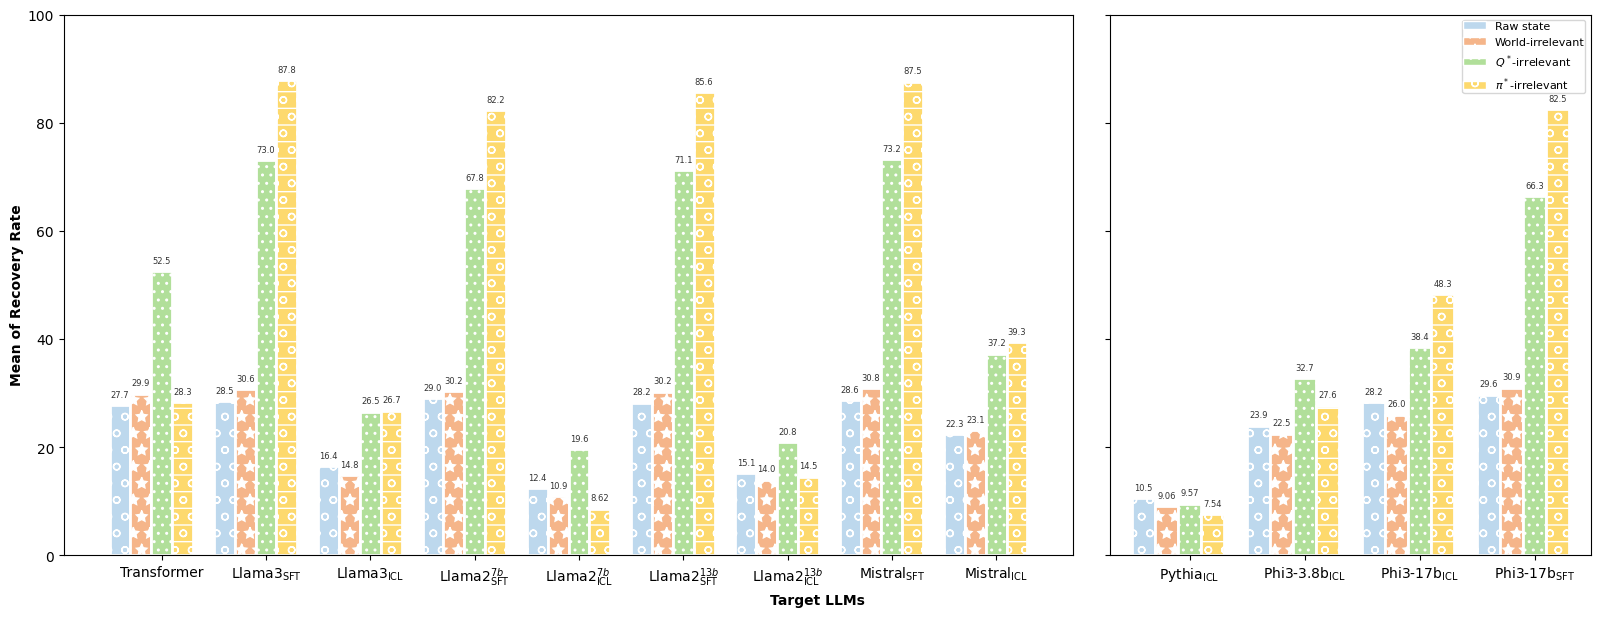

In [27]:
df_gripper_all = pd.read_csv(
    os.path.join(RESULTS_DIR, 'gripper_probe_all.csv')
    )
df_gripper_new = pd.read_csv(
    os.path.join(RESULTS_DIR, 'gripper_probe_all_new.csv')
    )
viz_pred_rslt(df_gripper_all, df_gripper_new, './plots/gripper-abs-mean.png', add_vals={
            "model": ["Transformer"],
            "raw": [27.7],
            "w": [29.9],
            "q": [52.5],
            "pi": [28.3]
        })

In [33]:
def plot_cook_pred_rslt(df_pred_rslt, save_to):
    # Data
    models = [LLMNameNorm[x] if x in LLMNameNorm.keys() else x for x in df_pred_rslt.model.values.tolist()]
    raw = df_pred_rslt.raw.values.tolist()
    w = df_pred_rslt.w.values.tolist()
    q = df_pred_rslt.q.values.tolist()
    pi = df_pred_rslt.pi.values.tolist()

    # Bar width
    bar_width = 0.2
    linewidth = 2.
    # Set position of bar on X axis
    r1 = np.arange(len(models))
    r2 = [x + bar_width for x in r1]
    r3 = [x + bar_width for x in r2]
    r4 = [x + bar_width for x in r3]

    plt.figure(figsize=(12,8))
    
    # Create the plot
    plt.bar(r1, raw, width=bar_width, color='#bdd8ed', label='Raw state', edgecolor='white', hatch="o", linewidth=linewidth)
    for x, v in zip(r1, raw):
        plt.text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    plt.bar(r2, w, width=bar_width, color='#F5B58A', label='Wolrd-irrelevant', edgecolor='white', hatch="*", linewidth=linewidth)
    for x, v in zip(r2, w):
        plt.text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    plt.bar(r3, q, width=bar_width, color='#B1DF9A', label=r'$Q^*$-irrelevant', edgecolor='white', hatch="..", linewidth=linewidth)
    for x, v in zip(r3, q):
        plt.text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    plt.bar(r4, pi, width=bar_width, color='#FDD96D', label=r'$\pi^*$-irrelevant', edgecolor='white', hatch="o-", linewidth=linewidth)
    for x, v in zip(r4, pi):
        plt.text(x, v+2, str(v)[:4], color='#333333', va='center', ha='center', fontsize=6)
    
    # Add xticks on the middle of the group bars
    plt.xlabel('Target LLMs', fontweight='bold')
    plt.ylabel('Mean of Recovery Rate', fontweight='bold')
    plt.xticks([r + 2 * bar_width for r in range(len(models))], models)
    plt.ylim([0, 100])
    
    # Create legend & Show graphic
    plt.legend([plt.Rectangle((0, 0), 2, 2, facecolor=color_map[x], hatch=hatch_map[x], edgecolor='white') for x in ['raw', 'w', 'q', 'pi']], 
    ['Raw state', 'World-irrelevant', r'$Q^*$-irrelevant', r'$\pi^*$-irrelevant'], borderpad=0.1, loc="upper left", fontsize=10,)
    #plt.show()
    plt.savefig(save_to, dpi=600)
    
def viz_pred_rslt_cook(df_pred_rslt, save_to, add_vals=None):
    df_pred_rslt_pivot = preproc_df(df_pred_rslt)
    df_pred_rslt_pivot_mean = get_df_mean(df_pred_rslt_pivot)
    random_row = df_pred_rslt_pivot_mean[df_pred_rslt_pivot_mean.model_name=='random'].iloc[0]
    df_methods = df_pred_rslt_pivot_mean[df_pred_rslt_pivot_mean.model_name!='random']
    df_pred_rslt = pd.DataFrame(df_methods.apply(lambda row: get_abs_perf(row, random_row), axis=1).tolist())
    df_pred_rslt = pd.concat([pd.DataFrame(add_vals), df_pred_rslt.sort_values('model')], ignore_index=True)
    plot_cook_pred_rslt(df_pred_rslt, save_to)

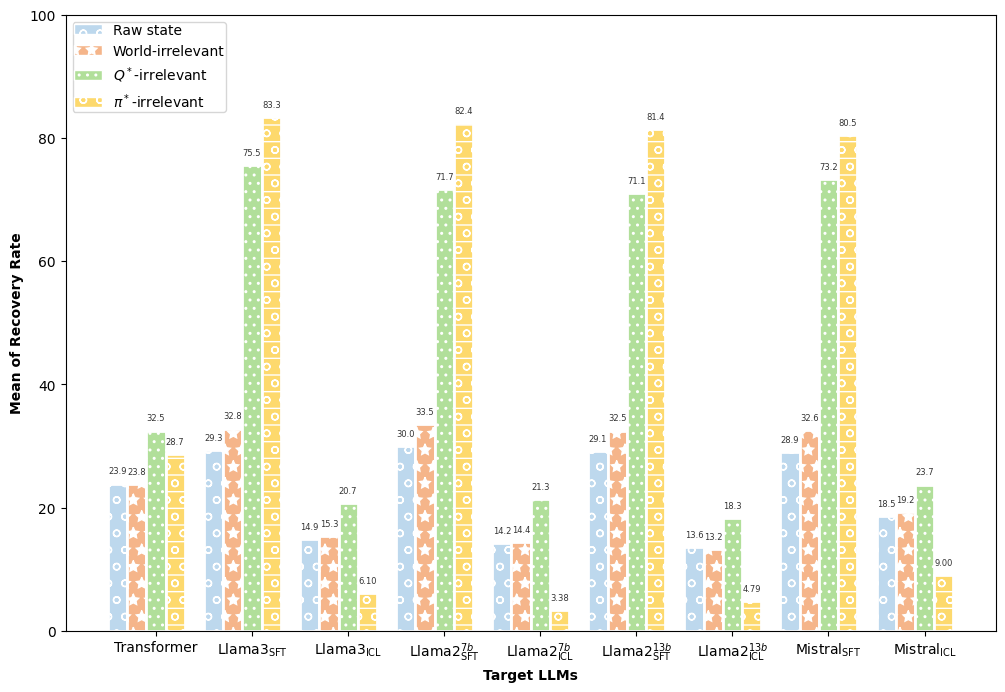

In [34]:
df_cook_all = pd.read_csv(
    os.path.join(RESULTS_DIR, 'cook_probe_all.csv')
)
viz_pred_rslt_cook(df_cook_all, './plots/cook-abs-mean.png', add_vals={
        "model": ["Transformer"],
        "raw": [23.9],
        "w": [23.8],
        "q": [32.5],
        "pi": [28.7]
    })

# Circle Bar

In [16]:
def make_long_rows_for_llm(row):
    new_rows = []
    for pred in [
        'agent-loc', 'box-content_g', 'box-content_u', 'box-name', 'held_g', 'held_u', 'nearby_t', 'nextObj', 'nextObjDirect', 'subgoal'
    ]:
        new_rows.append({
            'model_name': row.model_name,
            'pred_name': pred,
            'val': row[pred]
        })
    return new_rows

def flat_table(df):
    flat_dfs = []
    for row in df.iterrows():
        row = row[1]
        flat_dfs += make_long_rows_for_llm(row)
    return pd.DataFrame(flat_dfs)
    

def make_margin_circle(df):
    df_methods = df[~(df.model_name=='random')]
    df_random = df[df.model_name=='random']
    assert len(df_random) > 0
    df_methods['val'] = df_methods.apply(lambda row: renorm(row['val'], df_random[df_random.pred_name==row.pred_name].val.values[0]), axis=1)
    return df_methods

def precproc_df(df):
    df_flt = flat_table(df)
    df_flt['abs'] = df_flt.pred_name.apply(lambda x: PRED2ABS[x])
    df_flt['group'] = df_flt['abs'].apply(lambda x: x[-1])
    df_flt['group'] = pd.Categorical(df_flt['group'], ["raw", "q", "w", "pi"])
    df_flt = make_margin_circle(df_flt)
    df_flt['val'] = df_flt['val'].apply(lambda x: x*100)
    df_flt['max_val_in_pred'] = df_flt.apply(lambda row: df_flt[df_flt.pred_name==row.pred_name].val.max(), axis=1)
    df_flt = df_flt.sort_values(['group', 'pred_name', 'model_name']).reset_index(drop=True)
    return df_flt

In [35]:
def get_label_rotation(angle, offset):

    rotation = np.rad2deg(angle + offset)
    
    if angle <= np.pi:
        alignment = "right"
        #rotation = rotation - 180
    else: 
        alignment = "left"
    rotation = rotation - 90
    return rotation, alignment

In [34]:
def add_labels(angles, values, labels, offset, ax):
    
    # This is the space between the end of the bar and the label
    padding = 4
    
    # Iterate over angles, values, and labels, to add all of them.
    for angle, value, label, in zip(angles, values, labels):
        angle = angle
        
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        # And finally add the text
        ax.text(
            x=angle, 
            y=value + padding, 
            s=label, 
            ha=alignment, 
            va="center", 
            rotation=rotation, 
            rotation_mode="anchor"
        ) 

In [33]:
def add_pred_labels(angles, values, max_values, labels, offset, ax):
    
    # This is the space between the end of the bar and the label
    padding = 6
    
    # Iterate over angles, values, and labels, to add all of them.
    for i, (angle, value, maxv, label) in enumerate(zip(angles, values, max_values, labels)):
        
        angle = angle
        # Obtain text rotation and alignment
        rotation, alignment = get_label_rotation(angle, offset)

        plt.text(angle, value+4, str(value)[:4], color='#6d6d6d', va='center', ha='center', fontsize=9)
        if not i % 4 == 1: continue
        va = "top" if "box-content" in label or 'held' in label else 'bottom'
        ax.text(
            x=angle, 
            y=maxv + padding+6, 
            s=PRED2Latex[label],
            ha='center',#alignment, 
            va=va,#"bottom", 
            #rotation=rotation, 
            rotation_mode="anchor"
        ) 

In [20]:
color_map = {
    "raw": '#bdd8ed',
    "w": "#F5B58A",
    'q': '#B1DF9A',
    'pi': "#FDD96D"
}
hatch_map = ['||','', "."]

In [32]:
def draw_circular_bar(df_rslt, savefig_path, legend=False):
    df_rslt = precproc_df(df_rslt)
    ## All this part is like the code above

    VALUES = df_rslt["val"].values
    LABELS = df_rslt["pred_name"].values
    GROUP = df_rslt["group"].values
    PRED = df_rslt["pred_name"].values
    AllGroup = df_rslt['abs'].values
    MAX_VAL_IN_PRED = df_rslt['max_val_in_pred'].values
    NABS = [len(x) for x in AllGroup]
    PAD = 3
    sPAD = 1
    ANGLES_N = len(VALUES) + PAD * len(np.unique(GROUP)) + sPAD * len(np.unique(PRED))
    ANGLES = np.linspace(0, 2 * np.pi, num=ANGLES_N, endpoint=False)
    WIDTH = (2 * np.pi) / len(ANGLES)
    OFFSET = np.pi / 2

    GROUPS_SIZE = [len(i[1]) for i in df_rslt.groupby("group")]

    offset = PAD
    IDXS = []
    for size in GROUPS_SIZE:
        #IDXS += list(range(offset + PAD, offset + size + PAD))
        #offset += size + PAD
        #span = list(range(offset, offset + size + int((size//3)*sPAD)))

        for npred in range(size//4):
            
            IDXS += list(range(offset, offset + 4))
            offset += 4 + sPAD
        offset += PAD

    plt.rcParams['hatch.color'] = '#7A7A7A'
    fig, ax = plt.subplots(figsize=(20, 10), subplot_kw={"projection": "polar"})
    ax.set_theta_offset(OFFSET)
    ax.set_ylim(-38, 100)
    ax.set_frame_on(False)
    ax.xaxis.grid(False)
    ax.yaxis.grid(False)
    ax.set_xticks([])
    ax.set_yticks([])

    COLORS = [f"C{i}" for i, size in enumerate(GROUPS_SIZE) for _ in range(size)]


    # And finally add the bars. 
    # Note again the `ANGLES[IDXS]` to drop some angles that leave the space between bars.
    def alloc_vals(tensor, sizes, condition):
        return np.where(
            condition, 
            np.array(tensor)/np.array(sizes),
            0.
        )

    def plan_bottm(tensor, sizes, condition, cur_abs_i):
        return np.where(
            condition, 
            cur_abs_i*(np.array(tensor)/np.array(sizes)),
            0.
        )

    for i in range(4): # iterate over four LLM variants
        idxs_i = [v for x, v in enumerate(IDXS) if x%4==i]
        vals = [v for x, v in enumerate(VALUES) if x%4==i]
        all_abs = [v for x, v in enumerate(AllGroup) if x%4==i]
        nabs = [v for x, v in enumerate(NABS) if x%4==i]
        allgroup = [v for x, v in enumerate(AllGroup) if x%4==i]
        cur_vals = [0]* len(allgroup)
        for abs_i, abs in enumerate(df_rslt.group.unique().tolist()):
            tmp_vals = alloc_vals(vals, nabs, [abs in x for x in allgroup])
            collection = ax.bar(
                ANGLES[idxs_i], 
                tmp_vals, 
                width=WIDTH, color=color_map[abs], 
                linewidth=2, hatch=hatch_map[i], 
                edgecolor='white', 
                bottom=cur_vals
            )
            for patch in collection.patches:
                patch._hatch_color = (112, 112, 112 )

            cur_vals += tmp_vals
            
    plt.rcParams.update({
        "text.usetex": True,
        "font.size": 12,
    })

    add_pred_labels(ANGLES[IDXS], VALUES, MAX_VAL_IN_PRED, LABELS, OFFSET, ax)

    plt.rcParams.update({
        "text.usetex": False,
        #"font.size": 12,
        "font.family": "Sans"
    })
    
    offset = 0 
    offset2 = 0
    ax.set_rlabel_position(8)
    ax.grid(True, linewidth=0.2)
    ax.set_axisbelow(True)
    ax.set_rticks([0, 20, 40, 60, 80, 100], minor=False)
    for group, size in zip(["Raw", r"$Q^*$", "World", r"$\pi^*$"], GROUPS_SIZE):
        # Add line below bars
        x1 = np.linspace(ANGLES[offset + PAD], ANGLES[offset + size + int(sPAD*(size//4)) + PAD-2], num=50)
        ax.plot(x1, [-5] * 50, color="#333333")
        
        # Add text to indicate group
        if group == 'World-irrelevant':
            bias = -15
            rotation = 56
        else:
            bias = -20
            rotation = 0
        if group == "Raw state":
            bias = -10
            rotation = 25
        if group == r"$Q^*$-irrelevant":
            #bias = -13
            #rotation = 40
            bias = -13
            rotation = -60

        if group == r"$\pi^*$-irrelevant":
            rotation = -35
            bias = -11
        ax.text(
            np.mean(x1), -16, group, color="#333333", fontsize=14, 
            fontweight="bold", ha="center", va="bottom", font="Sans",# rotation = rotation
        )
        
        # Add reference lines at 20, 40, 60, and 80
        x2 = np.linspace(ANGLES[offset2-1], ANGLES[offset2 + PAD], num=50)

        
        offset += size + PAD + int(sPAD*(size//4)) 
        offset2 += size + PAD + int(sPAD*(size//4)) -1
    if legend:
        plt.legend(
            [plt.Rectangle((0, 0), 2, 2, facecolor=color_map[x], edgecolor='white') for x in ['raw', 'w', 'q', 'pi']] + [
                plt.Rectangle((0, 0), 2, 2, facecolor='white', edgecolor='#A3A3A3', hatch=['o','..', "", '|||'][i]) for i in range(4)], 
            ['Raw state', 'World-irrelevant', r'$Q^*$-irrelevant', r'$\pi^*$-irrelevant']+[
                r'Llama2$_{\text{SFT}}$', r'Llama2$_{\text{ICL}}$', r"Mistral$_{\text{SFT}}$", r"Mistral$_{\text{ICL}}$"], 
            borderpad=0.6, loc="upper left", fontsize=8, handlelength=2, handleheight=2)
    plt.savefig(savefig_path, dpi=600)

In [22]:
def preproc_prob_rslt(infile, models=None):
    df = pd.read_csv(infile)
    df_pivot = preproc_df(df)
    df_mean = get_df_mean(df_pivot)
    if models:
        df_mean = df_mean[df_mean.model_name.apply(lambda x: x in models)]
    return df_mean

In [23]:
df_gripper = preproc_prob_rslt(
    os.path.join(RESULTS_DIR, 'gripper_probe_all.csv'), models=['llama2', 'mistral', 'llama2-icl', 'mistral-icl', 'random']
)

/var/folders/z_/3fx7w2d576999j4q29v9n_8r0000gn/T/ipykernel_92529/1701659353.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_methods['val'] = df_methods.apply(lambda row: renorm(row['val'], df_random[df_random.pred_name==row.pred_name].val.values[0]), axis=1)
/var/folders/z_/3fx7w2d576999j4q29v9n_8r0000gn/T/ipykernel_92529/2750615102.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  GROUPS_SIZE = [len(i[1]) for i in df_rslt.groupby("group")]


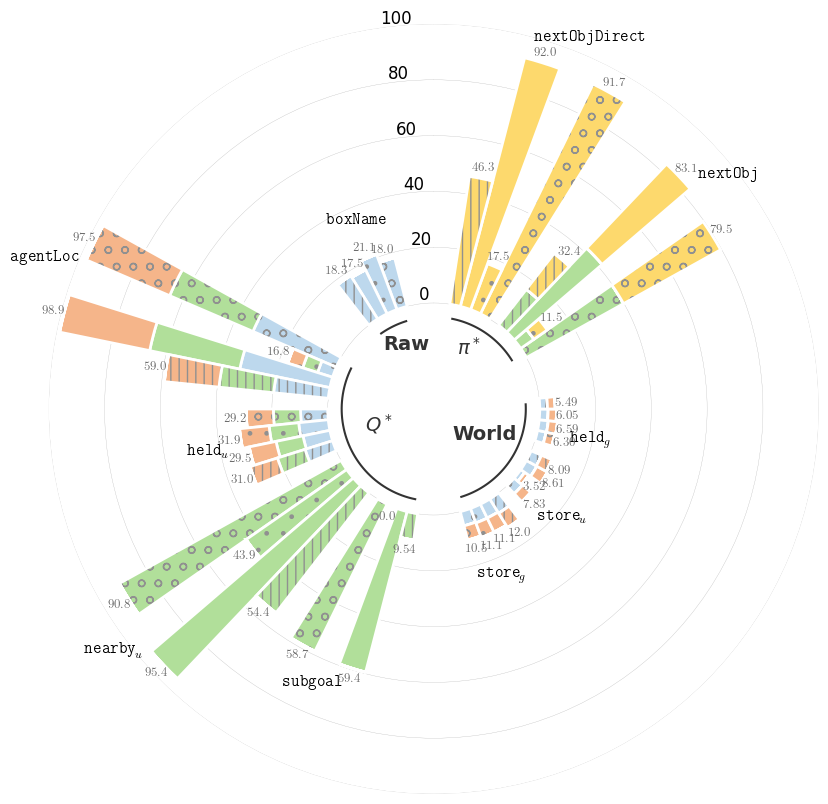

In [36]:
color_map = {
    "raw": '#bdd8ed',
    "w": "#F5B58A",
    'q': '#B1DF9A',
    'pi': "#FDD96D"
}
hatch_map = ['o','.', "", '||']
draw_circular_bar(df_gripper, './plots/gripper-circle.png')

/var/folders/z_/3fx7w2d576999j4q29v9n_8r0000gn/T/ipykernel_92529/1701659353.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_methods['val'] = df_methods.apply(lambda row: renorm(row['val'], df_random[df_random.pred_name==row.pred_name].val.values[0]), axis=1)
/var/folders/z_/3fx7w2d576999j4q29v9n_8r0000gn/T/ipykernel_92529/2750615102.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  GROUPS_SIZE = [len(i[1]) for i in df_rslt.groupby("group")]


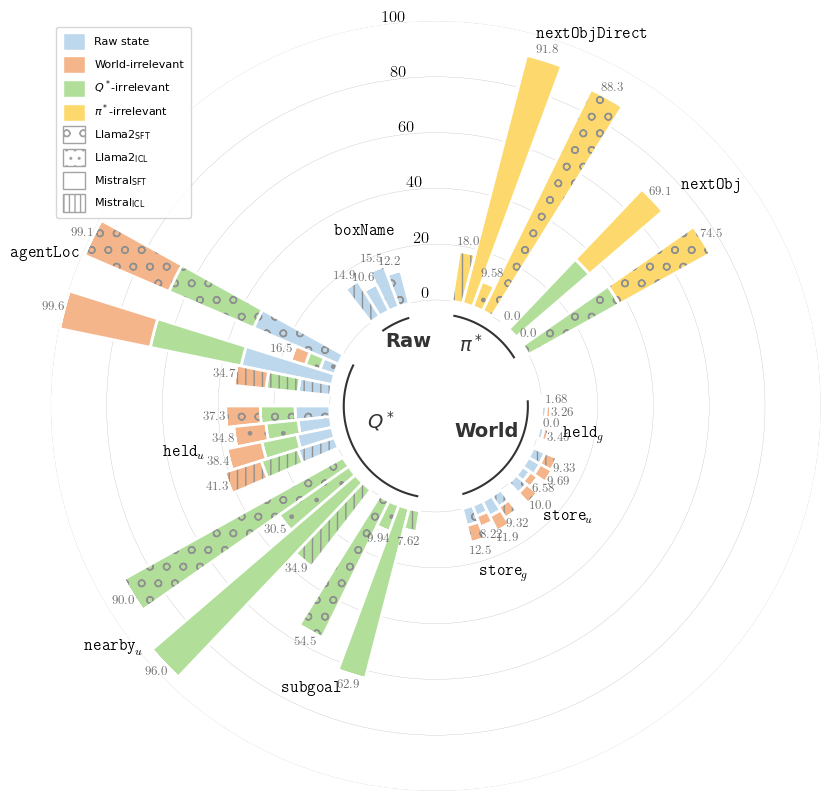

In [43]:
df_cook = preproc_prob_rslt(
    os.path.join(RESULTS_DIR, 'cook_probe_all.csv'), models=['llama2', 'mistral', 'llama2-icl', 'mistral-icl', 'random'])
draw_circular_bar(df_cook, './plots/cook-circle.png', legend=True)